<a href="https://colab.research.google.com/github/carlosmvond/Angelini_et_al_2026/blob/main/Angelini_et_al_2026_heatmap.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

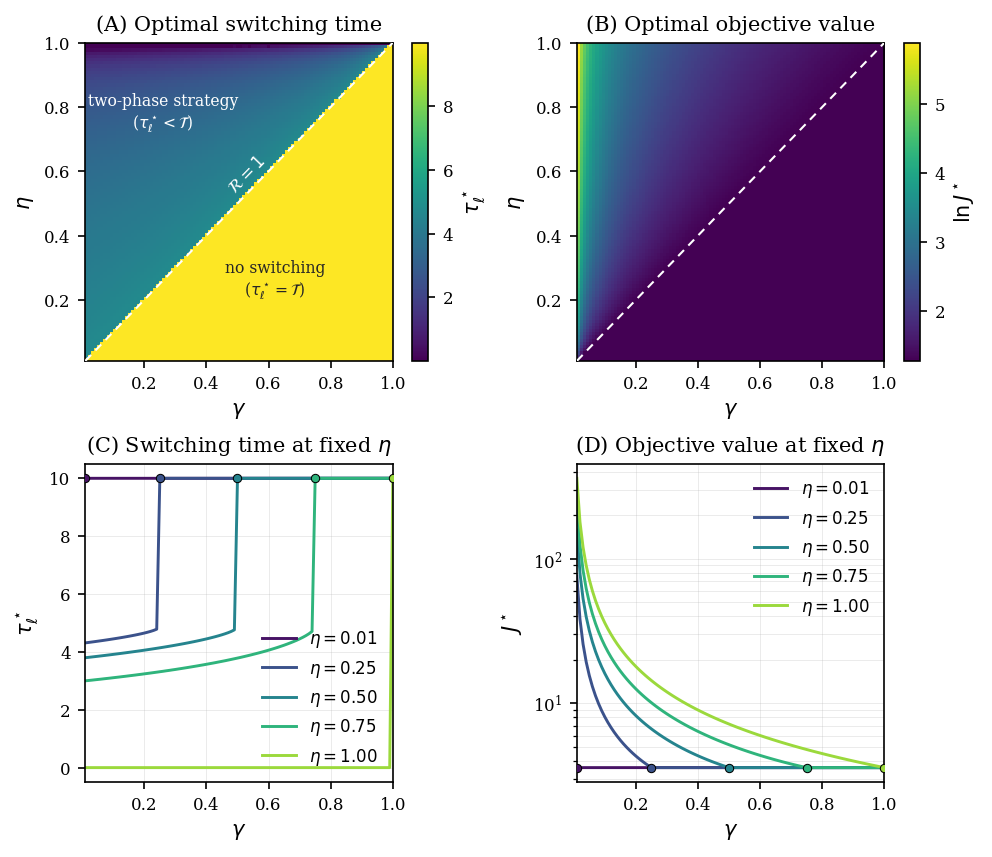

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os, urllib.request

# ============================================================
# Load data directly from GitHub (with local fallback)
# Repository: https://github.com/carlosmvond/Angelini_et_al_2026
# ============================================================
BASE = ("https://raw.githubusercontent.com/"
        "carlosmvond/Angelini_et_al_2026/main/")

def load_csv(name):
    """Read a CSV from the local folder if present, else from GitHub."""
    if os.path.exists(name):
        return np.loadtxt(name, delimiter=",")
    with urllib.request.urlopen(BASE + name) as f:
        return np.loadtxt(f, delimiter=",")

JJ = load_csv("sample100KJJ.csv")
TL = load_csv("sample100KTL.csv")

# ============================================================
# Publication settings
# ============================================================
plt.rcParams.update({
    "text.usetex": False,
    "font.family": "serif",
    "font.size": 9,
    "axes.labelsize": 10,
    "axes.titlesize": 10,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "legend.fontsize": 8,
    "figure.dpi": 150,
})

# ============================================================
# Parameter grid (must match the sweep used to generate the data)
# ============================================================
N = 100
eta_vals   = np.linspace(0.01, 1.0, N)
gamma_vals = np.linspace(0.01, 1.0, N)

extent = [gamma_vals[0], gamma_vals[-1], eta_vals[0], eta_vals[-1]]
g0, g1 = gamma_vals[0], gamma_vals[-1]

# slices to be shown in panels (C) and (D)
eta_slices = [0.01, 0.25, 0.50, 0.75, 1.00]

# ============================================================
# Figure: 2 x 2 layout
#   (A) heatmap tau_l        (B) heatmap ln J
#   (C) tau_l vs gamma       (D) J vs gamma
# ============================================================
fig, axes = plt.subplots(2, 2, figsize=(6.5, 5.6), constrained_layout=True)
axA, axB = axes[0, 0], axes[0, 1]
axC, axD = axes[1, 0], axes[1, 1]

# ---------- (A) optimal switching time ----------
im1 = axA.imshow(TL, origin="lower", aspect="auto", extent=extent,
                 cmap="viridis", interpolation="nearest")
cbar1 = fig.colorbar(im1, ax=axA, pad=0.02)
cbar1.set_label(r"$\tau_\ell^\star$")
axA.set_title(r"(A) Optimal switching time")

axA.text(0.62, 0.26, "no switching\n" + r"($\tau_\ell^\star=\mathcal{T}$)",
         color="0.15", fontsize=7.5, ha="center", va="center")
axA.text(0.26, 0.78, "two-phase strategy\n" + r"($\tau_\ell^\star<\mathcal{T}$)",
         color="w", fontsize=7.5, ha="center", va="center")

# ---------- (B) optimal objective value ----------
im2 = axB.imshow(np.log(np.maximum(JJ, 1e-12)), origin="lower",
                 aspect="auto", extent=extent,
                 cmap="viridis", interpolation="nearest")
cbar2 = fig.colorbar(im2, ax=axB, pad=0.02)
cbar2.set_label(r"$\ln J^\star$")
axB.set_title(r"(B) Optimal objective value")

# ---------- analytical threshold R = eta/gamma = 1 ----------
for ax in (axA, axB):
    ax.plot([g0, g1], [g0, g1], color="w", lw=1.0, ls=(0, (4, 3)),
            solid_capstyle="butt", zorder=3)
    ax.set_xlabel(r"$\gamma$")
    ax.set_ylabel(r"$\eta$")
    ax.set_xlim(g0, g1)
    ax.set_ylim(eta_vals[0], eta_vals[-1])

# ---------- (C) and (D): slices at fixed eta ----------
colors = plt.get_cmap("viridis")(np.linspace(0.05, 0.85, len(eta_slices)))

for eta_target, c in zip(eta_slices, colors):
    i = np.argmin(np.abs(eta_vals - eta_target))
    eta_i = eta_vals[i]
    label = rf"$\eta = {eta_i:.2f}$"

    axC.plot(gamma_vals, TL[i, :], color=c, lw=1.4, label=label)
    axD.plot(gamma_vals, JJ[i, :], color=c, lw=1.4, label=label)

    # threshold R = 1 occurs at gamma = eta
    j = np.argmin(np.abs(gamma_vals - eta_i))
    if abs(gamma_vals[j] - eta_i) < 0.02:
        axC.plot(gamma_vals[j], TL[i, j], "o", color=c, ms=4, mec="k", mew=0.5, zorder=3)
        axD.plot(gamma_vals[j], JJ[i, j], "o", color=c, ms=4, mec="k", mew=0.5, zorder=3)

axC.set_xlabel(r"$\gamma$")
axC.set_ylabel(r"$\tau_\ell^\star$")
axC.set_title(r"(C) Switching time at fixed $\eta$")
axC.set_xlim(g0, g1)
axC.grid(True, lw=0.3, alpha=0.4)
axC.legend(frameon=False, loc="lower right")

axD.set_xlabel(r"$\gamma$")
axD.set_ylabel(r"$J^\star$")
axD.set_yscale("log")
axD.set_title(r"(D) Objective value at fixed $\eta$")
axD.set_xlim(g0, g1)
axD.grid(True, which="both", lw=0.3, alpha=0.4)
axD.legend(frameon=False, loc="upper right")

# ---------- diagonal label, computed in display coordinates ----------
fig.canvas.draw()
p0 = axA.transData.transform((g0, g0))
p1 = axA.transData.transform((g1, g1))
angle = np.degrees(np.arctan2(p1[1] - p0[1], p1[0] - p0[0]))

axA.text(0.55, 0.57, r"$\mathcal{R}=1$", color="w", fontsize=8,
         rotation=angle, rotation_mode="anchor",
         ha="center", va="bottom", zorder=4)

# ============================================================
# Export
# ============================================================
for ext in ("eps", "pdf", "png"):
    fig.savefig(f"tl_production.{ext}", format=ext, bbox_inches="tight")

plt.show()

try:
    from google.colab import files
    files.download("tl_production.eps")
except ImportError:
    print("Figures saved as tl_production.{eps,pdf,png}")